# Notebook 06 — Basel III IRB Capital

## Central Question

**We calibrated a point-in-time PD for IFRS 9 provisioning. Basel IRB capital requires a through-the-cycle PD and a fundamentally different loss concept — unexpected loss at 99.9% confidence. How do we serve both regulatory regimes from one model, and what does the ASRF formula actually do to our PD to produce a stable, downturn-calibrated capital charge?**

## Why It Matters — The Two-Regime Problem

The same PD model feeds two regulatory regimes with opposite requirements. Confusing them is one of the most common errors in credit risk, so we state the distinction precisely before computing anything.

**IFRS 9 provisioning covers expected loss (EL)** — the loss anticipated on average, recognized through the P&L as a provision. It requires **point-in-time (PIT) PD**, reflecting current economic conditions, so that provisions *track the cycle*: they rise in a downturn and fall in a recovery. This is what Notebook 05 computed.

**Basel capital covers unexpected loss (UL)** — the loss *beyond* expected, measured at the 99.9th percentile of the one-year loss distribution, held as regulatory capital. It requires **through-the-cycle (TTC) PD**, a long-run average deliberately *insensitive* to the current cycle position, so that capital is *stable* and does not amplify the cycle.

| | IFRS 9 (Notebook 05) | Basel IRB (this notebook) |
|---|---|---|
| Loss concept | Expected loss (EL) | Unexpected loss (UL) |
| Confidence level | Mean (expected value) | 99.9th percentile |
| Held as | P&L provision | Regulatory capital |
| PD flavor | Point-in-time (PIT) | Through-the-cycle (TTC) |
| Cycle behavior | Tracks the cycle (intended) | Stable across cycle (intended) |
| Same borrower → | cycle-sensitive PD | cycle-stable PD |

The same borrower, the same model, the same underlying default probability — yet provisioning wants the PD to move with the cycle and capital wants it not to. A credit risk function manages both from a single model. **That tension is the subject of this notebook.**

## What This Dataset Supports

As in Notebook 05, the dataset provides PIT PD but no LGD, EAD, maturity, or macroeconomic history. We bridge with stated assumptions:

| Basel input | Source | Treatment |
|---|---|---|
| PD (PIT) | Champion model (Notebook 03) | Used directly as base case |
| PD (TTC) | No cycle history available | Illustrative adjustment in Section 7 (procyclicality demo) |
| LGD | Basel FIRB benchmark | 45% (as Notebook 05) |
| EAD | None | Unit exposure (capital expressed as rate) |
| Maturity (M) | None | Retail treatment (maturity adjustment dropped) |
| Asset correlation (R) | **Basel-prescribed** | Computed exactly from the regulatory retail formula |
| PD floor | Basel-prescribed | 0.03% floor applied |

Note that the asset correlation and PD floor are **regulatory constants**, not estimated quantities — these we implement faithfully. Per the Notebook 05 handoff, the base case computes IRB capital on the PIT PD (honest about the data), and Section 7 demonstrates the PIT→TTC adjustment and the procyclicality it addresses.

## Roadmap

1. Setup and the two-regime framing
2. Expected vs unexpected loss — the loss distribution
3. The PIT→TTC question
4. The ASRF formula, dissected (Vasicek conditional PD, EL subtraction, asset correlation)
5. IRB capital calculation — K, RWA, capital charge
6. Standardised Approach comparison
7. Procyclicality and sensitivity
8. Key finding and handoff to Notebook 07

## 1. Setup and the Two-Regime Framing

We load the champion PIT PD — the same artifact and re-scoring used in Notebook 05 — and fix the Basel-specific parameters. The portfolio frame carries forward unchanged; what changes is the regulatory lens applied to the PD.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import norm
import joblib

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42

# --- Load champion and re-score PIT PD (consistent with Notebook 05) ---
champion = joblib.load('../models/lr_champion.pkl')
model_lr     = champion['model']
logit_offset = champion['logit_offset']

X_test_woe = pd.read_csv('../data/X_test_woe.csv')
y_test     = pd.read_csv('../data/y_test.csv').squeeze()

def apply_prior_correction(p_raw, offset):
    p_clipped = np.clip(p_raw, 1e-15, 1 - 1e-15)
    logit_raw = np.log(p_clipped / (1 - p_clipped))
    return 1 / (1 + np.exp(-(logit_raw + offset)))

pd_pit = apply_prior_correction(model_lr.predict_proba(X_test_woe)[:, 1], logit_offset)

# --- Basel parameters ---
BASEL = {
    'LGD': 0.45,            # FIRB benchmark, as Notebook 05
    'EAD': 1.0,             # unit exposure → capital as a rate
    'confidence': 0.999,    # 99.9% — the IRB capital confidence level
    'pd_floor': 0.0003,     # 0.03% regulatory PD floor
}

# Apply the regulatory PD floor immediately (Basel requires PD >= 0.03%)
pd_pit_floored = np.maximum(pd_pit, BASEL['pd_floor'])
n_floored = (pd_pit < BASEL['pd_floor']).sum()

portfolio = pd.DataFrame({
    'pd_pit': pd_pit_floored,
    'actual_default': y_test.values,
    'EAD': BASEL['EAD'],
})

print(f"Borrowers:                 {len(portfolio):,}")
print(f"Mean PIT PD:               {portfolio['pd_pit'].mean():.4%}")
print(f"Median PIT PD:             {portfolio['pd_pit'].median():.4%}")
print(f"Borrowers below PD floor:  {n_floored:,} (raised to {BASEL['pd_floor']:.2%})")
print(f"\nBasel parameters:")
for k, v in BASEL.items():
    print(f"  {k:12s}: {v}")

Borrowers:                 30,000
Mean PIT PD:               7.0577%
Median PIT PD:             2.2576%
Borrowers below PD floor:  0 (raised to 0.03%)

Basel parameters:
  LGD         : 0.45
  EAD         : 1.0
  confidence  : 0.999
  pd_floor    : 0.0003


## 2. Expected vs Unexpected Loss — The Loss Distribution

Capital exists to absorb the loss that provisions do not. To see why, we look at the full distribution of possible portfolio losses over one year.

### The two quantities, formally

For a single exposure, **expected loss** is the mean of the loss distribution:

$$\text{EL} = \text{PD} \times \text{LGD} \times \text{EAD}$$

This is provisioned under IFRS 9. A bank expects to lose this much on average, prices it into the loan, and reserves for it.

**Unexpected loss** is the variability *around* that mean — the risk that realized losses in a given year exceed the expected. Capital is sized to cover this at a high confidence level. Basel sets the level at **99.9%**: capital must absorb losses up to the level exceeded only once in 1,000 years.

$$\text{Capital} = \text{Loss}_{99.9\%} - \text{EL}$$

Capital covers the gap between the 99.9% worst-case loss and the expected loss. The expected portion is already provisioned; capital covers only the unexpected excess. This subtraction is the formal bridge between the two regimes — and it appears explicitly inside the ASRF formula in Section 4.

### Why losses are not normally distributed

If defaults were independent, portfolio loss would be near-normal by the central limit theorem, and capital would be modest. They are not independent — defaults cluster, because borrowers share exposure to common economic conditions (the systematic risk factor). In a bad year, *many* borrowers default together. This correlation produces a **right-skewed, fat-tailed** loss distribution: most years see losses near the expected level, but occasional years see losses far above it. That fat tail is what drives the 99.9% capital requirement well above expected loss.

We illustrate this with a Monte Carlo simulation of correlated defaults using the single-factor (Vasicek) model that underlies the Basel framework.

In [2]:
def simulate_portfolio_loss(pd_vec, lgd, ead, asset_corr, n_sims=20000, seed=42):
    """
    Single-factor (Vasicek) Monte Carlo of one-year portfolio loss.

    Each borrower i defaults if a latent asset return A_i falls below its
    default threshold N^{-1}(PD_i). Asset returns share a common systematic
    factor M with loading sqrt(rho):
        A_i = sqrt(rho) * M + sqrt(1-rho) * eps_i
    M is the same draw for all borrowers in a given simulated year, inducing
    default correlation. eps_i is idiosyncratic.
    """
    rng = np.random.default_rng(seed)
    N = len(pd_vec)
    thresholds = norm.ppf(pd_vec)                      # (N,)
    sqrt_rho = np.sqrt(asset_corr)
    sqrt_1mrho = np.sqrt(1 - asset_corr)

    losses = np.empty(n_sims)
    # Simulate year by year (vectorized over borrowers)
    for s in range(n_sims):
        M = rng.standard_normal()                       # systematic factor (scalar per year)
        eps = rng.standard_normal(N)                    # idiosyncratic
        A = sqrt_rho * M + sqrt_1mrho * eps
        defaults = A < thresholds
        losses[s] = (defaults * lgd * ead).sum()
    return losses / (ead * N)                           # loss as fraction of exposure

# Use a representative retail asset correlation for the illustration (computed properly in Section 4)
RHO_ILLUSTRATIVE = 0.05

losses = simulate_portfolio_loss(
    portfolio['pd_pit'].values, BASEL['LGD'], BASEL['EAD'],
    asset_corr=RHO_ILLUSTRATIVE, n_sims=20000, seed=RANDOM_STATE
)

el_analytical = portfolio['pd_pit'].mean() * BASEL['LGD']
loss_999 = np.quantile(losses, 0.999)
loss_mean = losses.mean()
capital_999 = loss_999 - loss_mean

print("Monte Carlo portfolio loss distribution (single-factor, illustrative ρ=0.05):\n")
print(f"  Analytical EL (PD×LGD):       {el_analytical:.4%}")
print(f"  Simulated mean loss:          {loss_mean:.4%}")
print(f"  Simulated 99.9% loss:         {loss_999:.4%}")
print(f"  → Unexpected loss (capital):  {capital_999:.4%}")
print(f"  → Capital / EL ratio:         {capital_999/loss_mean:.2f}×")
print(f"\n  Loss distribution shape:")
print(f"    Skewness: {stats.skew(losses):.3f}  (>0 = right tail)")
print(f"    99.9% / mean: {loss_999/loss_mean:.2f}×  (tail extends well beyond the mean)")

Monte Carlo portfolio loss distribution (single-factor, illustrative ρ=0.05):

  Analytical EL (PD×LGD):       3.1760%
  Simulated mean loss:          3.1808%
  Simulated 99.9% loss:         7.2405%
  → Unexpected loss (capital):  4.0597%
  → Capital / EL ratio:         1.28×

  Loss distribution shape:
    Skewness: 0.791  (>0 = right tail)
    99.9% / mean: 2.28×  (tail extends well beyond the mean)


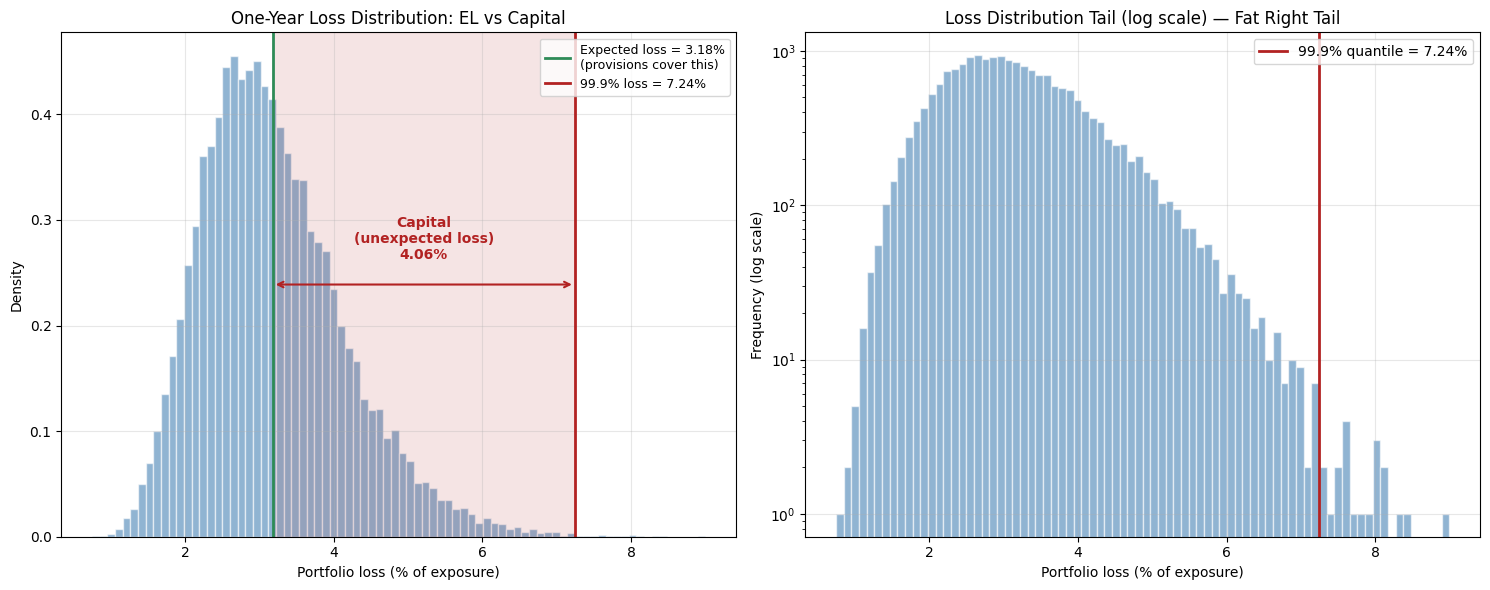

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Panel 1: the loss distribution with EL and capital marked
ax = axes[0]
ax.hist(losses * 100, bins=80, color='steelblue', alpha=0.6, edgecolor='white', density=True)
ax.axvline(loss_mean * 100, color='seagreen', linestyle='-', linewidth=2,
           label=f'Expected loss = {loss_mean:.2%}\n(provisions cover this)')
ax.axvline(loss_999 * 100, color='firebrick', linestyle='-', linewidth=2,
           label=f'99.9% loss = {loss_999:.2%}')
ax.axvspan(loss_mean * 100, loss_999 * 100, alpha=0.12, color='firebrick')
ax.annotate('', xy=(loss_999*100, ax.get_ylim()[1]*0.5),
            xytext=(loss_mean*100, ax.get_ylim()[1]*0.5),
            arrowprops=dict(arrowstyle='<->', color='firebrick', lw=1.5))
ax.text((loss_mean+loss_999)/2*100, ax.get_ylim()[1]*0.55,
        f'Capital\n(unexpected loss)\n{capital_999:.2%}',
        ha='center', color='firebrick', fontsize=10, fontweight='bold')
ax.set_xlabel('Portfolio loss (% of exposure)')
ax.set_ylabel('Density')
ax.set_title('One-Year Loss Distribution: EL vs Capital')
ax.legend(loc='upper right', fontsize=9)
ax.grid(alpha=0.3)

# Panel 2: the tail, log-scale, to show fatness
ax = axes[1]
ax.hist(losses * 100, bins=80, color='steelblue', alpha=0.6, edgecolor='white')
ax.axvline(loss_999 * 100, color='firebrick', linestyle='-', linewidth=2,
           label=f'99.9% quantile = {loss_999:.2%}')
ax.set_yscale('log')
ax.set_xlabel('Portfolio loss (% of exposure)')
ax.set_ylabel('Frequency (log scale)')
ax.set_title('Loss Distribution Tail (log scale) — Fat Right Tail')
ax.legend(loc='upper right')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/figures/06_loss_distribution.png', dpi=120, bbox_inches='tight')
plt.show()